# Exponential Phase: A Visual Notebook

This notebook translates the first three Exponential Phase notes into runnable notebook cells:

- `01-branching-depth-resolution.md`
- `02-discrete-phase-rulers.md`
- `03-hidden-generators.md`

The goal is to keep the core language of the papers, while adding small Python visuals for phase rulers, exact unfoldings, failed rulers, and hidden generators.


In [2]:
import math
from fractions import Fraction

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook uses matplotlib for visuals. Install it with `%pip install matplotlib` in a notebook cell, then rerun."
    ) from exc

plt.rcParams.update({
    "figure.figsize": (8, 3.8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## 1. Branching Depth Resolution

The starting point is the anchor pair:

$$b^0 = 1, \qquad b^1 = b$$

`1` is the origin. `b` is the endpoint of the first full phase span.

For a fixed branching factor `b`, the global depth sequence is:

$$\mathcal{D}_b = \{b^k \mid k \in \mathbb{N}_0\}$$

The base fixes the branching law. The exponent fixes the depth position.


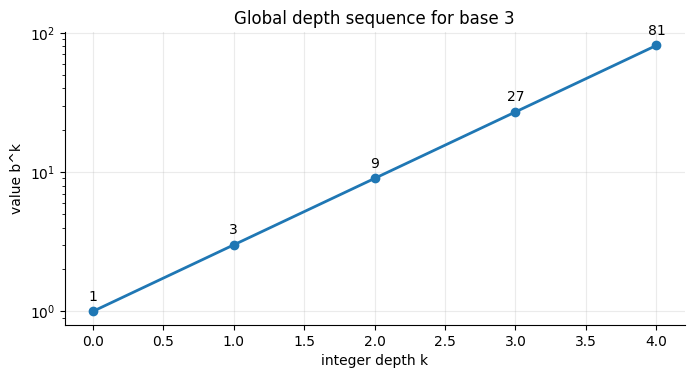

In [3]:
def depth_sequence(b, max_depth):
    return [b ** k for k in range(max_depth + 1)]


def plot_depth_sequence(b, max_depth=5):
    depths = list(range(max_depth + 1))
    values = depth_sequence(b, max_depth)

    fig, ax = plt.subplots()
    ax.plot(depths, values, marker="o", linewidth=2)
    for x, y in zip(depths, values):
        ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 8), ha="center")

    ax.set_title(f"Global depth sequence for base {b}")
    ax.set_xlabel("integer depth k")
    ax.set_ylabel("value b^k")
    ax.set_yscale("log")
    plt.show()


plot_depth_sequence(3, max_depth=4)


## 2. Rational Exponents as Phase Rulers

The central move is:

$$b^{n/a} = \left(b^{1/a}\right)^n$$

The denominator `a` cuts one coarse exponential jump into `a` equal exponent slices.

- `a` is the phase ruler.
- `1/a` is the primitive phase unit.
- `n/a` is the depth reached after `n` primitive phase steps.

The ruler lives in exponent space. The phase-value sequence lives in value space.


In [4]:
def phase_coordinates(a):
    return [Fraction(k, a) for k in range(a + 1)]


def phase_values(b, a):
    return [b ** (k / a) for k in range(a + 1)]


def exact_generator(b, a):
    """Return g when b = g^a with integer g >= 2; otherwise return None."""
    if b < 2 or a < 2:
        return None
    g = round(b ** (1 / a))
    return g if g >= 2 and g ** a == b else None


def phase_table(b, a):
    g = exact_generator(b, a)
    rows = []
    for k, coord in enumerate(phase_coordinates(a)):
        value = b ** (k / a)
        rows.append({
            "k": k,
            "phase": str(coord),
            "value": int(round(value)) if abs(value - round(value)) < 1e-10 else value,
            "as_generator_power": None if g is None else f"{g}^{k}",
        })
    return rows


phase_table(64, 6)


[{'k': 0, 'phase': '0', 'value': 1, 'as_generator_power': '2^0'},
 {'k': 1, 'phase': '1/6', 'value': 2, 'as_generator_power': '2^1'},
 {'k': 2, 'phase': '1/3', 'value': 4, 'as_generator_power': '2^2'},
 {'k': 3, 'phase': '1/2', 'value': 8, 'as_generator_power': '2^3'},
 {'k': 4, 'phase': '2/3', 'value': 16, 'as_generator_power': '2^4'},
 {'k': 5, 'phase': '5/6', 'value': 32, 'as_generator_power': '2^5'},
 {'k': 6, 'phase': '1', 'value': 64, 'as_generator_power': '2^6'}]

## 3. The Primitive First Phase Step

The primitive question is always:

$$b^{1/a}$$

If this first phase step is exact and lands in the natural numbers, then it becomes a hidden generator:

$$g = b^{1/a}$$

Then the whole phase sequence can be rewritten as:

$$b^{k/a} = g^k$$

So one exact micro-jump is enough to organize the whole unfolding.


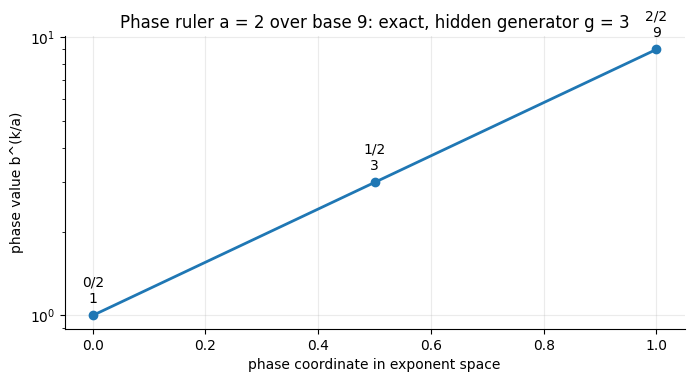

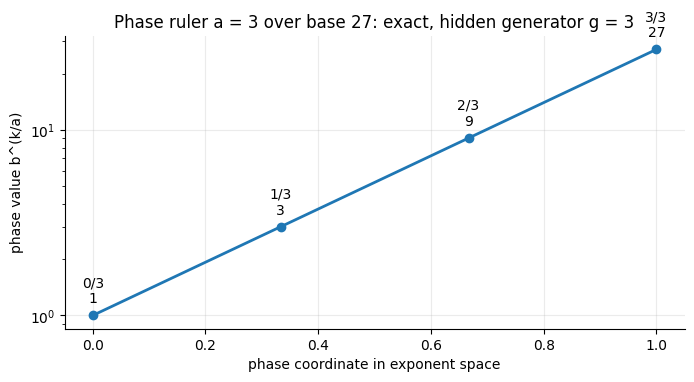

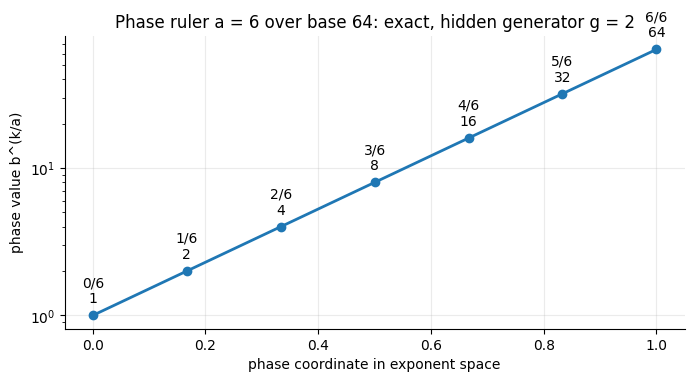

In [5]:
def plot_phase_ruler(b, a):
    xs = [k / a for k in range(a + 1)]
    ys = phase_values(b, a)
    g = exact_generator(b, a)

    fig, ax = plt.subplots()
    ax.plot(xs, ys, marker="o", linewidth=2)

    for k, (x, y) in enumerate(zip(xs, ys)):
        value_label = str(int(round(y))) if abs(y - round(y)) < 1e-10 else f"{y:.2f}"
        ax.annotate(
            f"{k}/{a}\n{value_label}",
            (x, y),
            textcoords="offset points",
            xytext=(0, 9),
            ha="center",
        )

    exact_text = f"exact, hidden generator g = {g}" if g is not None else "nonexact discrete ruler"
    ax.set_title(f"Phase ruler a = {a} over base {b}: {exact_text}")
    ax.set_xlabel("phase coordinate in exponent space")
    ax.set_ylabel("phase value b^(k/a)")
    ax.set_yscale("log")
    plt.show()


plot_phase_ruler(9, 2)
plot_phase_ruler(27, 3)
plot_phase_ruler(64, 6)


## 4. Exact and Nonexact Rulers

A ruler `a` is exact for base `b` when:

$$b^{1/a} \in \mathbb{N}$$

If the first phase step is exact, every accumulated phase is exact.

If the first phase step fails, the phases still exist over the reals, but they do not define an exact discrete node-by-node phase sequence.


In [6]:
for b, a in [(9, 2), (27, 3), (64, 2), (64, 3), (64, 6), (12, 2), (12, 3)]:
    g = exact_generator(b, a)
    status = f"exact with g = {g}" if g is not None else "nonexact"
    print(f"b={b:>4}, a={a:>2}: {status}")


b=   9, a= 2: exact with g = 3
b=  27, a= 3: exact with g = 3
b=  64, a= 2: exact with g = 8
b=  64, a= 3: exact with g = 4
b=  64, a= 6: exact with g = 2
b=  12, a= 2: nonexact
b=  12, a= 3: nonexact


## 5. One Endpoint, Several Rulers

`64` is the clean example:

$$64 = 8^2 = 4^3 = 2^6$$

So the same coarse endpoint admits several exact phase resolutions:

```text
1 -> 8 -> 64
1 -> 4 -> 16 -> 64
1 -> 2 -> 4 -> 8 -> 16 -> 32 -> 64
```

The finer the valid ruler, the deeper the exact unfolding.


In [7]:
def exact_pairs(B):
    """Return all nontrivial exact pairs (g, a) with B = g^a."""
    if B < 4:
        return []
    pairs = []
    max_a = int(math.log(B, 2)) + 1
    for a in range(2, max_a + 1):
        g = round(B ** (1 / a))
        if g >= 2 and g ** a == B:
            pairs.append((g, a))
    return sorted(pairs, key=lambda pair: pair[1])


exact_pairs(64)


[(8, 2), (4, 3), (2, 6)]

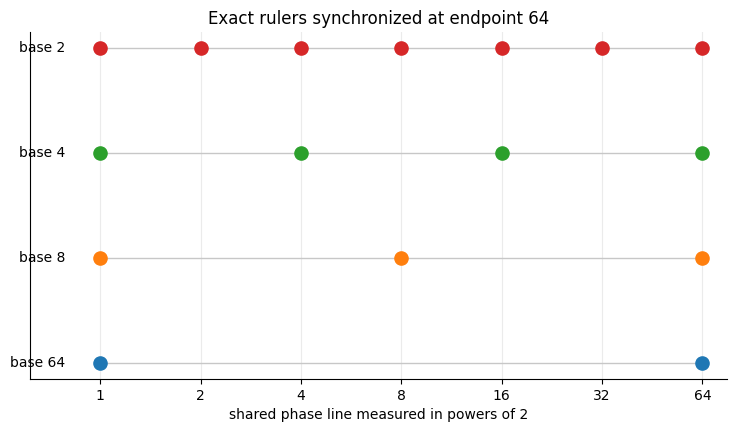

In [8]:
def plot_endpoint_sync(B):
    pairs = exact_pairs(B)
    if not pairs:
        print(f"{B} has no nontrivial exact hidden generators.")
        return

    finest_g = min(g for g, _ in pairs)
    max_level = round(math.log(B, finest_g))
    values = [finest_g ** level for level in range(max_level + 1)]

    tracks = [(B, 1)] + sorted(pairs, reverse=True)
    fig, ax = plt.subplots(figsize=(9, 4.5))

    for row, (g, a) in enumerate(tracks):
        step = max(1, round(math.log(g, finest_g)))
        levels = list(range(0, max_level + 1, step))
        ax.hlines(row, 0, max_level, color="0.78", linewidth=1)
        ax.scatter(levels, [row] * len(levels), s=90, zorder=3)
        ax.text(-0.35, row, f"base {g}", ha="right", va="center")

    ax.set_xticks(range(max_level + 1))
    ax.set_xticklabels(values)
    ax.set_yticks([])
    ax.set_xlim(-0.7, max_level + 0.25)
    ax.set_title(f"Exact rulers synchronized at endpoint {B}")
    ax.set_xlabel(f"shared phase line measured in powers of {finest_g}")
    plt.show()


plot_endpoint_sync(64)


## 6. Hidden Generators

When the first exact phase step lands in the natural numbers, it is no longer only a value. It becomes a new local branching base.

If:

$$g = b^{1/a}$$

then:

$$b = g^a$$

The generator and the ruler appear together:

- `a` tells us how many exact phase steps fit in the coarse span.
- `g` tells us what local base generates those steps.


In [9]:
def generator_family(B):
    return [g for g, _ in exact_pairs(B)]


for B in [9, 12, 27, 64, 256, 4096]:
    print(f"Gamma({B}) = {generator_family(B)}; exact pairs = {exact_pairs(B)}")


Gamma(9) = [3]; exact pairs = [(3, 2)]
Gamma(12) = []; exact pairs = []
Gamma(27) = [3]; exact pairs = [(3, 3)]
Gamma(64) = [8, 4, 2]; exact pairs = [(8, 2), (4, 3), (2, 6)]
Gamma(256) = [16, 4, 2]; exact pairs = [(16, 2), (4, 4), (2, 8)]
Gamma(4096) = [64, 16, 8, 4, 2]; exact pairs = [(64, 2), (16, 3), (8, 4), (4, 6), (2, 12)]


## 7. Generator Families

For a fixed endpoint `B`, the full family of exact hidden generators is:

$$\Gamma(B) = \{g \in \mathbb{N}_{\ge 2} \mid \exists a \in \mathbb{N}_{\ge 2}\text{ such that }B = g^a\}$$

This set may be empty, a singleton, or a family.

- `12` has no nontrivial exact generator.
- `9` and `27` each reveal `3`.
- `64` reveals `2`, `4`, and `8`.


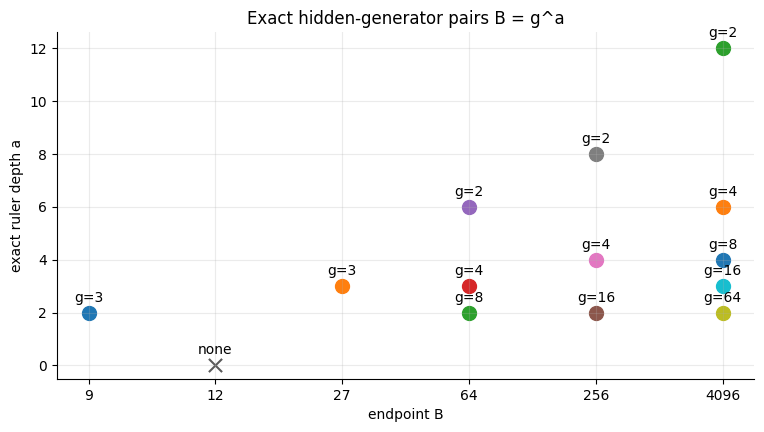

In [10]:
def plot_generator_pairs(B_values):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    plotted = False

    for x, B in enumerate(B_values):
        pairs = exact_pairs(B)
        if not pairs:
            ax.scatter([x], [0], marker="x", s=90, color="0.35")
            ax.annotate("none", (x, 0), textcoords="offset points", xytext=(0, 8), ha="center")
            continue

        plotted = True
        for g, a in pairs:
            ax.scatter([x], [a], s=100)
            ax.annotate(f"g={g}", (x, a), textcoords="offset points", xytext=(0, 8), ha="center")

    ax.set_xticks(range(len(B_values)))
    ax.set_xticklabels([str(B) for B in B_values])
    ax.set_xlabel("endpoint B")
    ax.set_ylabel("exact ruler depth a")
    ax.set_title("Exact hidden-generator pairs B = g^a")
    if plotted:
        ax.set_ylim(bottom=-0.5)
    plt.show()


plot_generator_pairs([9, 12, 27, 64, 256, 4096])


## 8. Depth Windows

A phase ruler is not tied only to the first interval `0 <= e <= 1`.

It can be shifted into any unit depth window:

$$m \le e \le m + 1$$

The phase points become:

$$b^m,\quad b^{m+1/a},\quad b^{m+2/a},\quad \dots,\quad b^{m+a/a}=b^{m+1}$$

Example: inside the base-`9` jump from `9` to `81`, the two-phase ruler reveals `27`.


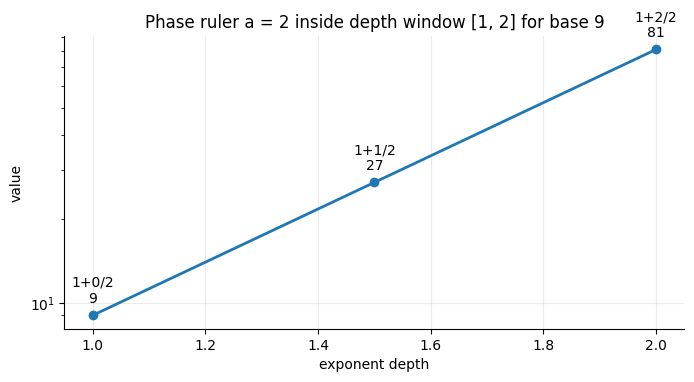

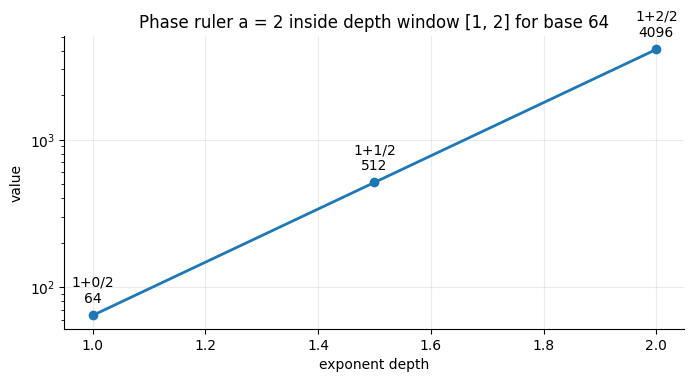

In [11]:
def window_phase_values(b, a, m):
    return [b ** (m + k / a) for k in range(a + 1)]


def plot_depth_window(b, a, m):
    xs = [m + k / a for k in range(a + 1)]
    ys = window_phase_values(b, a, m)

    fig, ax = plt.subplots()
    ax.plot(xs, ys, marker="o", linewidth=2)
    for k, (x, y) in enumerate(zip(xs, ys)):
        ax.annotate(
            f"{m}+{k}/{a}\n{int(round(y))}",
            (x, y),
            textcoords="offset points",
            xytext=(0, 9),
            ha="center",
        )

    ax.set_title(f"Phase ruler a = {a} inside depth window [{m}, {m + 1}] for base {b}")
    ax.set_xlabel("exponent depth")
    ax.set_ylabel("value")
    ax.set_yscale("log")
    plt.show()


plot_depth_window(9, 2, 1)
plot_depth_window(64, 2, 1)


## 9. Head, Tail, and Unfolding

If:

$$B = g^a$$

then:

- `1` is the origin.
- `g` is the hidden generator, or head.
- `B` is the coarse endpoint, or tail.

The full unfolding is:

$$\left(B^{0/a}, B^{1/a}, \dots, B^{a/a}\right) = \left(1, g, g^2, \dots, g^a\right)$$

The tail already contains the head implicitly. The phase ruler reveals the intermediate layers between them.


In [13]:
def print_unfolding(B, g, a):
    if g ** a != B:
        print(f"{B} != {g}^{a}; this is not an exact unfolding.")
        return
    values = [g ** k for k in range(a + 1)]
    print(" -> ".join(str(value) for value in values))


print_unfolding(64, 8, 2)
print_unfolding(64, 4, 3)
print_unfolding(64, 2, 6)
print_unfolding(4096, 2, 12)


1 -> 8 -> 64
1 -> 4 -> 16 -> 64
1 -> 2 -> 4 -> 8 -> 16 -> 32 -> 64
1 -> 2 -> 4 -> 8 -> 16 -> 32 -> 64 -> 128 -> 256 -> 512 -> 1024 -> 2048 -> 4096


## 10. Summary

The three notes combine into one compact principle:

1. A coarse exponential jump starts at `1` and ends at `b`.
2. A rational exponent introduces a phase ruler over that jump.
3. The primitive test is the first phase step `b^(1/a)`.
4. If that step is an integer, it becomes a hidden generator `g`.
5. The coarse jump unfolds as an exact discrete phase sequence: `1, g, g^2, ..., g^a = b`.

So a rational exponent can act as a depth-resolution operator over a branching structure.
